# **Tutorial:** Custom YOLO Object Detection with RoboFlow

In this tutorial, you'll learn how to create a custom YOLO object detection model using your own classes and annotations with RoboFlow.

### **Step 1: Install Required Dependencies**

In [1]:
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install roboflow
%pip install matplotlib
%pip install numpy==1.26.4 --force-reinstall

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.26.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp39-cp39-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


### **Step 2: Import Required Libraries**

In [2]:
import cv2
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import Image, display

### **Step 3: Set Up RoboFlow Account**

1. Go to RoboFlow and create a free account
2. Create a new project and select "Object Detection" as project type
3. Choose "YOLOv26" as the model format

### **Step 4: Upload and Annotate Your Images**

#### Using RoboFlow Web Interface:

1. Click "Upload" to add your images
2. Use the annotation tool to draw bounding boxes around objects
3. Assign the correct class labels to each bounding box
4. Apply preprocessing and augmentation as needed

### **Step 5. Download your Custom your Dataset**

1. In RoboFlow, go to your project dashboard
2. Click "Generate" to create a dataset version
3. Apply any desired augmentations
4. Click "Export" and select "YOLOv**x**" format (**x** the version you are using)
5. Copy the download code

In [4]:
%pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="uugD71oI3JrBihabx7vV")
project = rf.workspace("eugenio-tblbg").project("computer_vision_uide")
version = project.version(1)
dataset = version.download("yolo26")      

Note: you may need to restart the kernel to use updated packages.
loading Roboflow workspace...
loading Roboflow project...


### **Step 6: Train Your Custom YOLO Model**

In [5]:
OUTPUT_DIR = 'runs/detect/custom_yolo_model'

# Load the YOLO model with custom configuration
model = YOLO('yolo26n.pt')  # Using nano version as base

# Train the model on your custom dataset
results = model.train(
    data=f'{dataset.location}/data.yaml',  # Path to dataset config
    epochs=20,  # Number of training epochs
    imgsz=640,  # Image size
    batch=8,   # Batch size
    name='custom_yolo_model'  # Name for the training run
)

Ultralytics 8.4.172 🚀 Python-3.9.6 torch-2.8.0 CPU (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/eugenio/Documents/ComputerVision/UC.04 Object Detection/computer_vision_UIDE-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yolo_m

### **Step 7: Evaluate Your Model**

In [6]:
# Evaluate model performance
metrics = model.val()  # Validate the model
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")

# Show some validation results
!yolo task=detect mode=val model=runs/detect/custom_yolo_model/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.172 🚀 Python-3.9.6 torch-2.8.0 CPU (Apple M4 Pro)
YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 113.6±0.0 MB/s, size: 33.4 KB)
val: Scanning /Users/eugenio/Documents/ComputerVision/UC.04 Object Detection/computer_vision_UIDE-1/valid/labels.cache... 1 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 466.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 20.0it/s 0.0s
                   all          1          1    0.00333          1      0.995      0.547
Speed: 0.2ms preprocess, 44.9ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /Users/eugenio/Documents/Notebooks_ArtificialIntelligence/runs/detect/val
mAP50-95: 0.54725
mAP50: 0.995

    Arguments received: ['yolo', 'task=detect', 'mode=val', 'model=runs/detect/custom_yolo_model/weights/best.pt', 'data=/Users/eugenio/Documents/Compute

### **Step 8: Test Your Custom Model on an Image**


image 1/1 /Users/eugenio/Documents/ComputerVision/UC.04 Object Detection/taza_test.jpg: 640x640 57 tazas, 31.6ms
Speed: 1.2ms preprocess, 31.6ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


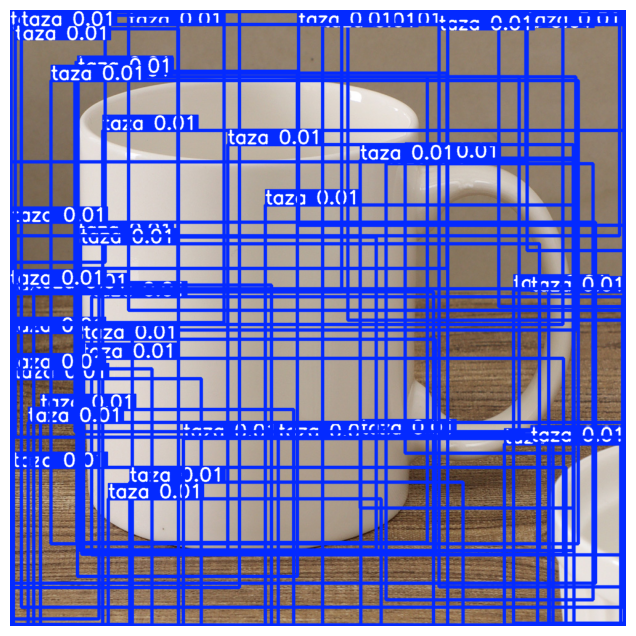

In [ ]:
# Load your custom trained model
custom_model = YOLO('/Users/eugenio/Documents/ComputerVision/UC.04 Object Detection/runs/detect/custom_yolo_model/weights/best.pt')

# Test on a sample image
results = custom_model('/Users/eugenio/Documents/ComputerVision/UC.04 Object Detection/taza_test.jpg', conf=0.25)

# Display results
%matplotlib inline
for result in results:
    img = result.plot()  # Plot detections
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

### **Step 9: Test Your Custom Model on Video**

In [ ]:
# Write your code here..



## **Activity: Create Your Custom Detector**

1. **Create a RoboFlow account** and set up a new project
2. **Upload at least 25 images** of your custom objects (at least 2)
3. **Annotate all images** with bounding boxes and class labels
4. **Train a YOLO model** on your custom dataset
5. **Test your model** on new images and evaluate its performance
6. **Implement real-time detection** with your custom classes

## **Grading Rubric:**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. Dataset Creation** | 4 | Successfully creates and annotates a custom dataset with at least 25 images and multiple classes in RoboFlow. |
| **2. Model Training** | 1 | Properly trains a YOLOv26 model on the custom dataset with appropriate hyperparameters. |
| **3. Model Evaluation** | 1 | Evaluates model performance with appropriate metrics and provides analysis of results. |
| **4. Custom Detection** | 3 | Implements real-time detection with custom classes and displays results correctly. You have to use video from your webcam, no images or saved videos allowed. |
| **5. Documentation** | 1 | Provides clear documentation of the process, including dataset details and model performance. |

**Total: 10 points**

## **Tips for Success:**

- **Quality over quantity**: Well-annotated images are more important than many poorly annotated ones
- **Class balance**: Try to have a similar number of examples for each class
- **Variety**: Include different angles, lighting conditions, and backgrounds
- **Augmentation**: Use RoboFlow's augmentation features to expand your dataset

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>